In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

zip_path = "/content/drive/MyDrive/garbage classification p.../dataset/archive.zip"

print(zip_path)
print(os.path.exists(zip_path))

/content/drive/MyDrive/garbage classification p.../dataset/archive.zip
False


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'IMG-20231027-WA0003.jpg', 'IMG-20231027-WA0004.jpg', 'IMG_20240423_151339.jpg', '1-015b07c7-0815-428f-866b-9fda217ea61f.pdf', 'Screenshot_2025-01-21-12-22-16-764_com.google.android.gm.jpg', 'IMG_20250306_133705.jpg', 'My Resume.pdf', '1751019669831.jpeg', 'Untitled form.gform', 'Veera Sandhya.gform', '0ed85da0-785a-46b9-af76-4a8725cadd3a.docx', 'Veera Sandhya (Responses).gsheet', 'Mandapati_Veera_Sandhya-10b77b56-08-2025.pdf .pdf', 'Untitled folder', 'Screenshot_2025-11-09-09-54-46-406_cn.wps.xiaomi.abroad.lite-edit.jpg', 'IMG_20251206_205010.jpg', 'Resume_Table_Format-1 (1).pdf', 'Resume_Table_Format-1.pdf', 'PDFGallery_20251212_210955.pdf', 'Bhavss resume.pdf', 'Bhavss resume.gdoc', 'garbage classification project', '.ipynb_checkpoints']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/garbage classification project"))


['.ipynb_checkpoints', 'dataset']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/garbage classification project/dataset"))

['.ipynb_checkpoints', 'archive.zip']


In [ ]:
import os

# Create the destination directory if it doesn't exist
output_dir = "/content/dataset"
os.makedirs(output_dir, exist_ok=True)

# Unzip the archive.zip from Google Drive to the specified output directory
!unzip "/content/drive/MyDrive/garbage classification project/dataset/archive.zip" -d "{output_dir}"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Garbage classification/Garbage classification/cardboard/cardboard152.jpg  
  inflating: /content/dataset/Garbage classification/Garbage classification/cardboard/cardboard153.jpg  
  inflating: /content/dataset/Garbage classification/Garbage classification/cardboard/cardboard154.jpg  
  inflating: /content/dataset/Garbage classification/Garbage classification/cardboard/cardboard155.jpg  
  inflating: /content/dataset/Garbage classification/Garbage classification/cardboard/cardboard156.jpg  
  inflating: /content/dataset/Garbage classification/Garbage classification/cardboard/cardboard157.jpg  
  inflating: /content/dataset/Garbage classification/Garbage classification/cardboard/cardboard158.jpg  
  inflating: /content/dataset/Garbage classification/Garbage classification/cardboard/cardboard159.jpg  
  inflating: /content/dataset/Garbage classification/Garbage classification/cardboard/cardboard16.jpg  
  inf

In [ ]:
import os

print(os.listdir("/content/dataset"))


['Garbage classification', 'garbage classification', 'one-indexed-files-notrash_test.txt', 'one-indexed-files-notrash_val.txt', 'one-indexed-files.txt', 'one-indexed-files-notrash_train.txt', 'zero-indexed-files.txt']


In [ ]:
import os

path = "/content/dataset/Garbage classification/Garbage classification"

print(os.listdir(path))

['glass', 'metal', 'cardboard', 'paper', 'trash', 'plastic']


In [ ]:
dataset_path = "/content/dataset/Garbage classification/Garbage classification"

print(os.listdir(dataset_path))

['glass', 'metal', 'cardboard', 'paper', 'trash', 'plastic']


In [ ]:
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json (from kaggle.com/settings -> API -> Create New Token)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d asdasdasasdas/garbage-classification
!unzip -q garbage-classification.zip -d garbage_data

Saving archive.zip to archive.zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
100% 82.0M/82.0M [00:00<00:00, 257MB/s]



In [ ]:
DATA_DIR = None
for root, dirs, files_ in os.walk("garbage_data"):
    if len(dirs) >= 5:  # the folder containing the 6 class subfolders
        DATA_DIR = root
        break

print("Detected data dir:", DATA_DIR)
print("Classes found:", os.listdir(DATA_DIR))

Detected data dir: garbage_data/Garbage classification/Garbage classification
Classes found: ['glass', 'metal', 'cardboard', 'paper', 'trash', 'plastic']


In [ ]:
BASE_DIR = "garbage_split"
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

classes = [c for c in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, c))]
val_ratio = 0.2

for cls in classes:
    src = os.path.join(DATA_DIR, cls)
    imgs = os.listdir(src)
    random.shuffle(imgs)
    split = int(len(imgs) * (1 - val_ratio))
    for phase, subset in [("train", imgs[:split]), ("val", imgs[split:])]:
        dst = os.path.join(BASE_DIR, phase, cls)
        os.makedirs(dst, exist_ok=True)
        for img in subset:
            shutil.copy(os.path.join(src, img), os.path.join(dst, img))

print("Classes:", classes)
print("Train counts:", {c: len(os.listdir(f"{BASE_DIR}/train/{c}")) for c in classes})
print("Val counts:", {c: len(os.listdir(f"{BASE_DIR}/val/{c}")) for c in classes})ASE_DIR = "garbage_split"

Classes: ['glass', 'metal', 'cardboard', 'paper', 'trash', 'plastic']
Train counts: {'glass': 400, 'metal': 328, 'cardboard': 322, 'paper': 475, 'trash': 109, 'plastic': 385}
Val counts: {'glass': 101, 'metal': 82, 'cardboard': 81, 'paper': 119, 'trash': 28, 'plastic': 97}


In [ ]:
IMG_SIZE = (300, 300)   # EfficientNetB3's native input size
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    f"{BASE_DIR}/train", target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    f"{BASE_DIR}/val", target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

NUM_CLASSES = train_gen.num_classes
print(train_gen.class_indices)

Found 2019 images belonging to 6 classes.
Found 508 images belonging to 6 classes.
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False  # freeze for stage 1

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 11,184,693 (42.67 MB)

 Trainable params: 398,086 (1.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint("best_stage1.keras", monitor="val_accuracy", save_best_only=True),
]

In [ ]:
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.7405 - loss: 0.8218 - val_accuracy: 0.8602 - val_loss: 0.4841 - learning_rate: 0.0010
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 888ms/step - accuracy: 0.8687 - loss: 0.3944 - val_accuracy: 0.8661 - val_loss: 0.4047 - learning_rate: 0.0010
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 870ms/step - accuracy: 0.8782 - loss: 0.3469 - val_accuracy: 0.8563 - val_loss: 0.3608 - learning_rate: 0.0010
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 891ms/step - accuracy: 0.9044 - loss: 0.2747 - val_accuracy: 0.8799 - val_loss: 0.3282 - learning_rate: 0.0010
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 865ms/step - accuracy: 0.9203 - loss: 0.2378 - val_accuracy: 0.8760 - val_loss: 0.3315 - learning_rate: 0.0010
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 83s 877ms/step - accuracy: 0.9208 - loss: 0.2365 - val_accuracy: 0.9055 - val_loss: 0.2944 - learning_rate: 0.0010
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 853ms/step - accuracy: 0.9262 - loss: 0.21

In [ ]:
base_model.trainable = True
# Freeze the first ~70% of layers, fine-tune the rest
fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # much smaller LR for fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_ft = [
    EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint("best_finetuned.keras", monitor="val_accuracy", save_best_only=True),
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks_ft
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.8014 - loss: 0.5956 - val_accuracy: 0.8937 - val_loss: 0.4055 - learning_rate: 1.0000e-05
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 879ms/step - accuracy: 0.8375 - loss: 0.4691 - val_accuracy: 0.8661 - val_loss: 0.4762 - learning_rate: 1.0000e-05
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 878ms/step - accuracy: 0.8603 - loss: 0.3915 - val_accuracy: 0.8484 - val_loss: 0.5334 - learning_rate: 1.0000e-05
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 873ms/step - accuracy: 0.8821 - loss: 0.3382 - val_accuracy: 0.8484 - val_loss: 0.5534 - learning_rate: 1.0000e-05
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 909ms/step - accuracy: 0.8737 - loss: 0.3557 - val_accuracy: 0.8406 - val_loss: 0.5692 - learning_rate: 5.0000e-06
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 913ms/step - accuracy: 0.8895 - loss: 0.3117 - val_accuracy: 0.8445 - val_loss: 0.5696 - learning_rate: 5.0000e-06
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 57s 883ms/step - accur

In [ ]:
val_loss, val_acc = model.evaluate(val_gen)
print(f"Final validation accuracy: {val_acc*100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.8937 - loss: 0.4055
Final validation accuracy: 89.37%


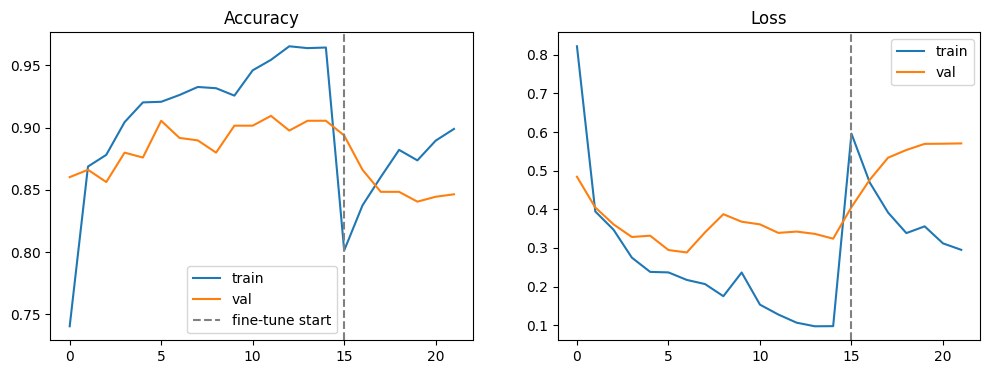

In [ ]:
def plot_history(h1, h2):
    acc = h1.history["accuracy"] + h2.history["accuracy"]
    val_acc = h1.history["val_accuracy"] + h2.history["val_accuracy"]
    loss = h1.history["loss"] + h2.history["loss"]
    val_loss = h1.history["val_loss"] + h2.history["val_loss"]

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(acc, label="train"); plt.plot(val_acc, label="val")
    plt.axvline(len(h1.history["accuracy"]), color="gray", linestyle="--", label="fine-tune start")
    plt.title("Accuracy"); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(loss, label="train"); plt.plot(val_loss, label="val")
    plt.axvline(len(h1.history["loss"]), color="gray", linestyle="--")
    plt.title("Loss"); plt.legend()
    plt.show()

plot_history(history1, history2)

In [ ]:
recycling_advice = {
    "cardboard": "Recyclable — flatten and place in paper/cardboard recycling.",
    "glass": "Recyclable — rinse and place in glass recycling bin.",
    "metal": "Recyclable — rinse cans, place in metal recycling.",
    "paper": "Recyclable — keep dry, place in paper recycling.",
    "plastic": "Check resin code; most PET/HDPE plastics are recyclable.",
    "trash": "Not recyclable — dispose in general waste.",
}

def classify_and_recommend(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    arr = tf.keras.preprocessing.image.img_to_array(img)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)

    pred = model.predict(arr)[0]
    idx = np.argmax(pred)
    label = class_names[idx]
    confidence = pred[idx] * 100

    print(f"Predicted: {label} ({confidence:.1f}% confidence)")
    print(f"Recommendation: {recycling_advice.get(label, 'No advice available.')}")
    return label, confidence

# Example:
# classify_and_recommend("garbage_split/val/plastic/plastic123.jpg")

In [ ]:
# Save in native Keras format (recommended)
model.save("garbage_classifier_efficientnetb3.keras")

# Also save just the weights (smaller, useful if you rebuild the architecture later)
model.save_weights("garbage_classifier_efficientnetb3.weights.h5")

print("Saved successfully.")

Saved successfully.


In [ ]:
import json

with open("class_indices.json", "w") as f:
    json.dump(train_gen.class_indices, f)

print(train_gen.class_indices)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
from google.colab import files

files.download("garbage_classifier_efficientnetb3.keras")
files.download("class_indices.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy("garbage_classifier_efficientnetb3.keras", "/content/drive/MyDrive/garbage_classifier_efficientnetb3.keras")
shutil.copy("class_indices.json", "/content/drive/MyDrive/class_indices.json")

print("Saved to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Google Drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Create a folder in Drive for this project
!mkdir -p /content/drive/MyDrive/garbage_classification

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/garbage_classification/data"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['IMG-20231027-WA0003.jpg', 'IMG-20231027-WA0004.jpg', 'IMG_20240423_151339.jpg', '1-015b07c7-0815-428f-866b-9fda217ea61f.pdf', 'Screenshot_2025-01-21-12-22-16-764_com.google.android.gm.jpg', 'IMG_20250306_133705.jpg', 'My Resume.pdf', 'Colab Notebooks', '1751019669831.jpeg', 'Untitled form.gform', 'Veera Sandhya.gform', '0ed85da0-785a-46b9-af76-4a8725cadd3a.docx', 'Veera Sandhya (Responses).gsheet', 'Mandapati_Veera_Sandhya-10b77b56-08-2025.pdf .pdf', 'Untitled folder', 'Screenshot_2025-11-09-09-54-46-406_cn.wps.xiaomi.abroad.lite-edit.jpg', 'IMG_20251206_205010.jpg', 'Resume_Table_Format-1 (1).pdf', 'Resume_Table_Format-1.pdf', 'PDFGallery_20251212_210955.pdf', 'Bhavss resume.pdf', 'Bhavss resume.gdoc', 'garbage classification project', '.ipynb_checkpoints', 'garbage_classifier_efficientnetb3.keras', 'class_indices.json', 'garbage_classification']


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.lower().endswith(".zip"):
            print(os.path.join(root, file))

/content/drive/MyDrive/garbage classification project/dataset/archive.zip


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/garbage classification project/dataset/archive.zip"

extract_path = "/content/drive/MyDrive/garbage classification project/dataset/extracted"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

print("Extraction completed successfully!")
print(os.listdir(extract_path))

Extraction completed successfully!
['Garbage classification', 'garbage classification', 'one-indexed-files-notrash_test.txt', 'one-indexed-files-notrash_train.txt', 'one-indexed-files-notrash_val.txt', 'one-indexed-files.txt', 'zero-indexed-files.txt']


In [ ]:
import os

for root, dirs, files in os.walk(extract_path):
    if dirs:
        print(root)
        print(dirs)

/content/drive/MyDrive/garbage classification project/dataset/extracted
['Garbage classification', 'garbage classification']
/content/drive/MyDrive/garbage classification project/dataset/extracted/Garbage classification
['Garbage classification']
/content/drive/MyDrive/garbage classification project/dataset/extracted/Garbage classification/Garbage classification
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
/content/drive/MyDrive/garbage classification project/dataset/extracted/garbage classification
['Garbage classification']
/content/drive/MyDrive/garbage classification project/dataset/extracted/garbage classification/Garbage classification
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
dataset_path = "/content/drive/MyDrive/garbage classification project/dataset/extracted/Garbage classification/Garbage classification"

In [ ]:
import os

print(os.listdir(dataset_path))

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Check if you previously saved the split folder to Drive
possible_split = "/content/drive/MyDrive/garbage_classification/garbage_split"

if os.path.exists(possible_split):
    print("Found existing split at:", possible_split)
    print(os.listdir(possible_split))
else:
    print("No existing split found — you'll need to recreate it (see next cell).")

No existing split found — you'll need to recreate it (see next cell).


In [ ]:
import os

DATA_DIR = "/content/drive/MyDrive/garbage classification project/dataset/extracted/Garbage classification/Garbage classification"

BASE_DIR = "garbage_split"

print("DATA_DIR exists:", os.path.exists(DATA_DIR))
print("BASE_DIR exists:", os.path.exists(BASE_DIR))

DATA_DIR exists: True
BASE_DIR exists: False


In [ ]:
import os
import shutil
import random

BASE_DIR = "garbage_split"

if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

classes = [
    c for c in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, c))
]

val_ratio = 0.2

random.seed(42)

for cls in classes:
    src = os.path.join(DATA_DIR, cls)

    imgs = [
        f for f in os.listdir(src)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(imgs)

    split = int(len(imgs) * (1 - val_ratio))

    for phase, subset in [
        ("train", imgs[:split]),
        ("val", imgs[split:])
    ]:
        dst = os.path.join(BASE_DIR, phase, cls)
        os.makedirs(dst, exist_ok=True)

        for img in subset:
            shutil.copy(
                os.path.join(src, img),
                os.path.join(dst, img)
            )

print("Classes:", classes)

print(
    "Train counts:",
    {c: len(os.listdir(f"{BASE_DIR}/train/{c}")) for c in classes}
)

print(
    "Val counts:",
    {c: len(os.listdir(f"{BASE_DIR}/val/{c}")) for c in classes}
)

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train counts: {'cardboard': 322, 'glass': 400, 'metal': 328, 'paper': 475, 'plastic': 385, 'trash': 109}
Val counts: {'cardboard': 81, 'glass': 101, 'metal': 82, 'paper': 119, 'plastic': 97, 'trash': 28}


In [ ]:
f"{BASE_DIR}/train"
f"{BASE_DIR}/val"

'garbage_split/val'

In [ ]:
import os

print(os.listdir("garbage_split/val"))

['glass', 'metal', 'cardboard', 'paper', 'trash', 'plastic']


In [ ]:
print("BASE_DIR:", BASE_DIR)
print("Train:", os.listdir("garbage_split/train"))
print("Val:", os.listdir("garbage_split/val"))

BASE_DIR: garbage_split
Train: ['glass', 'metal', 'cardboard', 'paper', 'trash', 'plastic']
Val: ['glass', 'metal', 'cardboard', 'paper', 'trash', 'plastic']


In [ ]:
import numpy as np
import json
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
IMG_SIZE_R = (224, 224)
BATCH_SIZE = 32

train_datagen_r = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
)

val_datagen_r = ImageDataGenerator(preprocessing_function=resnet_preprocess)

train_gen_r = train_datagen_r.flow_from_directory(
    f"{BASE_DIR}/train", target_size=IMG_SIZE_R, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True
)
val_gen_r = val_datagen_r.flow_from_directory(
    f"{BASE_DIR}/val", target_size=IMG_SIZE_R, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

NUM_CLASSES = train_gen_r.num_classes
class_names_r = list(train_gen_r.class_indices.keys())
print(train_gen_r.class_indices)

Found 2019 images belonging to 6 classes.
Found 508 images belonging to 6 classes.
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
y_train_r = train_gen_r.classes
class_weights_r = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_r),
    y=y_train_r
)
class_weight_dict_r = dict(enumerate(class_weights_r))
print(class_weight_dict_r)

{0: np.float64(1.045031055900621), 1: np.float64(0.84125), 2: np.float64(1.0259146341463414), 3: np.float64(0.708421052631579), 4: np.float64(0.874025974025974), 5: np.float64(3.0871559633027523)}


In [ ]:
base_model_r = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE_R, 3)
)
base_model_r.trainable = False

x = base_model_r.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

resnet_model = Model(inputs=base_model_r.input, outputs=outputs)
resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,711,430 (94.27 MB)

 Trainable params: 1,119,622 (4.27 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_r1 = [
    EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint("best_resnet_stage1.keras", monitor="val_accuracy", save_best_only=True),
]

history_r1 = resnet_model.fit(
    train_gen_r,
    validation_data=val_gen_r,
    epochs=20,
    class_weight=class_weight_dict_r,
    callbacks=callbacks_r1
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 66s 783ms/step - accuracy: 0.6241 - loss: 1.2604 - val_accuracy: 0.7854 - val_loss: 0.5594 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 523ms/step - accuracy: 0.7588 - loss: 0.7370 - val_accuracy: 0.8425 - val_loss: 0.4403 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 517ms/step - accuracy: 0.7766 - loss: 0.6476 - val_accuracy: 0.8445 - val_loss: 0.4025 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 517ms/step - accuracy: 0.8044 - loss: 0.5567 - val_accuracy: 0.8563 - val_loss: 0.4125 - learning_rate: 0.0010
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 523ms/step - accuracy: 0.8554 - loss: 0.4268 - val_accuracy: 0.8563 - val_loss: 0.4205 - learning_rate: 0.0010
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 520ms/step - accuracy: 0.8668 - loss: 0.3893 - val_accuracy: 0.8583 - val_loss: 0.4125 - learning_rate: 0.0010
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 505ms/step - accuracy: 0.8668 - loss: 0.

In [ ]:
base_model_r.trainable = True
fine_tune_at_r = int(len(base_model_r.layers) * 0.3)  # unfreeze last 70%
for layer in base_model_r.layers[:fine_tune_at_r]:
    layer.trainable = False

resnet_model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_r2 = [
    EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint("best_resnet_stage2.keras", monitor="val_accuracy", save_best_only=True),
]

history_r2 = resnet_model.fit(
    train_gen_r,
    validation_data=val_gen_r,
    epochs=30,
    class_weight=class_weight_dict_r,
    callbacks=callbacks_r2
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8727 - loss: 0.3824 - val_accuracy: 0.8957 - val_loss: 0.3122 - learning_rate: 5.0000e-06
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 577ms/step - accuracy: 0.8821 - loss: 0.3585 - val_accuracy: 0.8937 - val_loss: 0.3186 - learning_rate: 5.0000e-06
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 568ms/step - accuracy: 0.8915 - loss: 0.2963 - val_accuracy: 0.8839 - val_loss: 0.3331 - learning_rate: 5.0000e-06
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 561ms/step - accuracy: 0.9000 - loss: 0.2945 - val_accuracy: 0.8839 - val_loss: 0.3368 - learning_rate: 5.0000e-06
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 573ms/step - accuracy: 0.8955 - loss: 0.2697 - val_accuracy: 0.8878 - val_loss: 0.3398 - learning_rate: 2.5000e-06
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 549ms/step - accuracy: 0.9089 - loss: 0.2351 - val_accuracy: 0.8799 - val_loss: 0.3415 - learning_rate: 2.5000e-06
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 571ms/step - accur

In [ ]:
base_model_r.trainable = True  # unfreeze everything

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_r3 = [
    EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    ModelCheckpoint("best_resnet_final.keras", monitor="val_accuracy", save_best_only=True),
]

history_r3 = resnet_model.fit(
    train_gen_r,
    validation_data=val_gen_r,
    epochs=15,
    class_weight=class_weight_dict_r,
    callbacks=callbacks_r3
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8762 - loss: 0.3545 - val_accuracy: 0.8898 - val_loss: 0.3328
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 596ms/step - accuracy: 0.8712 - loss: 0.3463 - val_accuracy: 0.8839 - val_loss: 0.3485
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 574ms/step - accuracy: 0.8876 - loss: 0.3100 - val_accuracy: 0.8760 - val_loss: 0.3590
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 581ms/step - accuracy: 0.8772 - loss: 0.3262 - val_accuracy: 0.8701 - val_loss: 0.3642
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 585ms/step - accuracy: 0.8955 - loss: 0.2732 - val_accuracy: 0.8681 - val_loss: 0.3669
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 566ms/step - accuracy: 0.8950 - loss: 0.2733 - val_accuracy: 0.8701 - val_loss: 0.3669
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 585ms/step - accuracy: 0.8900 - loss: 0.2865 - val_accuracy: 0.8642 - val_loss: 0.3649


In [ ]:
val_loss_r, val_acc_r = resnet_model.evaluate(val_gen_r)
print(f"ResNet50 final validation accuracy: {val_acc_r*100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.8898 - loss: 0.3328
ResNet50 final validation accuracy: 88.98%


In [ ]:
resnet_model.save("garbage_classifier_resnet50.keras")

with open("class_indices_resnet.json", "w") as f:
    json.dump(train_gen_r.class_indices, f)

from google.colab import files
files.download("garbage_classifier_resnet50.keras")
files.download("class_indices_resnet.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step
              precision    recall  f1-score   support

   cardboard       0.97      0.89      0.93        81
       glass       0.90      0.81      0.85       101
       metal       0.86      0.89      0.87        82
       paper       0.90      0.94      0.92       119
     plastic       0.87      0.92      0.89        97
       trash       0.77      0.86      0.81        28

    accuracy                           0.89       508
   macro avg       0.88      0.88      0.88       508
weighted avg       0.89      0.89      0.89       508



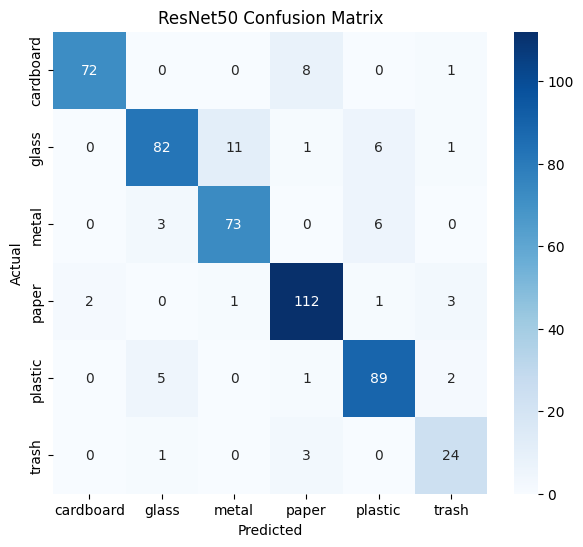

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

val_gen_r.reset()
preds_r = resnet_model.predict(val_gen_r)
y_pred_r = np.argmax(preds_r, axis=1)
y_true_r = val_gen_r.classes

print(classification_report(y_true_r, y_pred_r, target_names=class_names_r))

cm_r = confusion_matrix(y_true_r, y_pred_r)
plt.figure(figsize=(7,6))
sns.heatmap(cm_r, annot=True, fmt="d", xticklabels=class_names_r, yticklabels=class_names_r, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_DIR = "/content/drive/MyDrive/garbage classification project/dataset/extracted/Garbage classification/Garbage classification"

In [ ]:
import os

print(os.listdir(DATA_DIR))

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image

from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

BASE_DIR = "/content/drive/MyDrive/garbage_classification/garbage_split"
print("Classes:", os.listdir(f"{BASE_DIR}/train"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
removed = []

for phase in ["train", "val"]:
    for cls in os.listdir(f"{BASE_DIR}/{phase}"):
        folder = f"{BASE_DIR}/{phase}/{cls}"
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            ext = os.path.splitext(fname)[1].lower()

            if ext not in valid_extensions:
                os.remove(fpath)
                removed.append(fpath)
                continue

            try:
                img = Image.open(fpath)
                img.verify()
            except Exception:
                os.remove(fpath)
                removed.append(fpath)

print(f"Removed {len(removed)} bad/non-image files.")
for f in removed:
    print(" -", f)

Removed 1 bad/non-image files.
 - /content/drive/MyDrive/garbage_classification/garbage_split/train/glass/glass355.jpg


In [ ]:
def mobilenet_manual_preprocess(img):
    img = img / 127.5
    img = img - 1.0
    return img

IMG_SIZE_M = (224, 224)
BATCH_SIZE = 32

train_datagen_m = ImageDataGenerator(
    preprocessing_function=mobilenet_manual_preprocess,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
)

val_datagen_m = ImageDataGenerator(preprocessing_function=mobilenet_manual_preprocess)

train_gen_m = train_datagen_m.flow_from_directory(
    f"{BASE_DIR}/train", target_size=IMG_SIZE_M, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True
)
val_gen_m = val_datagen_m.flow_from_directory(
    f"{BASE_DIR}/val", target_size=IMG_SIZE_M, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

NUM_CLASSES = train_gen_m.num_classes
class_names_m = list(train_gen_m.class_indices.keys())
print("Class indices:", train_gen_m.class_indices)

# Sanity check
batch_x, batch_y = next(train_gen_m)
print("Pixel range:", batch_x.min(), "to", batch_x.max())

Found 2018 images belonging to 6 classes.
Found 508 images belonging to 6 classes.
Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Pixel range: -1.0 to 1.0


In [ ]:
y_train_m = train_gen_m.classes
class_weights_m = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_m), y=y_train_m
)
class_weight_dict_m = dict(enumerate(class_weights_m))
print(class_weight_dict_m)

{0: np.float64(1.044513457556936), 1: np.float64(0.8429406850459482), 2: np.float64(1.0254065040650406), 3: np.float64(0.7080701754385965), 4: np.float64(0.8735930735930736), 5: np.float64(3.085626911314985)}


In [ ]:
base_model_m = MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE_M, 3),
    include_preprocessing=False
)
base_model_m.trainable = False

x = base_model_m.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

mobilenet_model = Model(inputs=base_model_m.input, outputs=outputs)
mobilenet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation_20[0]… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu_19[0][0]    │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation_20[0]… │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_20[0][0]    │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_21 (ReLU)     │ (None, 56, 56,    │          0 │ expanded_conv_1_

 Total params: 3,558,662 (13.58 MB)

 Trainable params: 560,390 (2.14 MB)

 Non-trainable params: 2,998,272 (11.44 MB)

In [ ]:
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

callbacks_m1 = [
    EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint("best_mobilenet_stage1.keras", monitor="val_accuracy", save_best_only=True),
]

history_m1 = mobilenet_model.fit(
    train_gen_m,
    validation_data=val_gen_m,
    epochs=20,
    class_weight=class_weight_dict_m,
    callbacks=callbacks_m1
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.5808 - loss: 1.4106 - val_accuracy: 0.8150 - val_loss: 0.8372 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 596ms/step - accuracy: 0.7488 - loss: 1.0065 - val_accuracy: 0.8799 - val_loss: 0.7785 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 556ms/step - accuracy: 0.7874 - loss: 0.9239 - val_accuracy: 0.8720 - val_loss: 0.7626 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 577ms/step - accuracy: 0.8201 - loss: 0.8584 - val_accuracy: 0.8661 - val_loss: 0.7443 - learning_rate: 0.0010
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 567ms/step - accuracy: 0.8503 - loss: 0.8118 - val_accuracy: 0.8740 - val_loss: 0.7246 - learning_rate: 0.0010
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 582ms/step - accuracy: 0.8622 - loss: 0.7945 - val_accuracy: 0.8780 - val_loss: 0.7359 - learning_rate: 0.0010
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 576ms/step - accuracy: 0.8746 - loss: 0.765

In [ ]:
base_model_m.trainable = True
fine_tune_at_m = int(len(base_model_m.layers) * 0.3)
for layer in base_model_m.layers[:fine_tune_at_m]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

callbacks_m2 = [
    EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint("best_mobilenet_stage2.keras", monitor="val_accuracy", save_best_only=True),
]

history_m2 = mobilenet_model.fit(
    train_gen_m,
    validation_data=val_gen_m,
    epochs=30,
    class_weight=class_weight_dict_m,
    callbacks=callbacks_m2
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.7760 - loss: 0.9465 - val_accuracy: 0.9075 - val_loss: 0.6861 - learning_rate: 5.0000e-06
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 591ms/step - accuracy: 0.7958 - loss: 0.9113 - val_accuracy: 0.8996 - val_loss: 0.6992 - learning_rate: 5.0000e-06
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 568ms/step - accuracy: 0.8097 - loss: 0.8780 - val_accuracy: 0.8976 - val_loss: 0.7130 - learning_rate: 5.0000e-06
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 596ms/step - accuracy: 0.7944 - loss: 0.8814 - val_accuracy: 0.8976 - val_loss: 0.7240 - learning_rate: 5.0000e-06
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 584ms/step - accuracy: 0.8176 - loss: 0.8544 - val_accuracy: 0.8937 - val_loss: 0.7294 - learning_rate: 2.5000e-06
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 573ms/step - accuracy: 0.8350 - loss: 0.8417 - val_accuracy: 0.8917 - val_loss: 0.7303 - learning_rate: 2.5000e-06
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 613ms/step - accur

In [ ]:
base_model_m.trainable = True

mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

callbacks_m3 = [
    EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    ModelCheckpoint("best_mobilenet_final.keras", monitor="val_accuracy", save_best_only=True),
]

history_m3 = mobilenet_model.fit(
    train_gen_m,
    validation_data=val_gen_m,
    epochs=15,
    class_weight=class_weight_dict_m,
    callbacks=callbacks_m3
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.8043 - loss: 0.8964 - val_accuracy: 0.9035 - val_loss: 0.6985
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 572ms/step - accuracy: 0.7958 - loss: 0.8940 - val_accuracy: 0.8937 - val_loss: 0.7106
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 639ms/step - accuracy: 0.7998 - loss: 0.8937 - val_accuracy: 0.8957 - val_loss: 0.7197
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 586ms/step - accuracy: 0.8067 - loss: 0.8856 - val_accuracy: 0.8898 - val_loss: 0.7255
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 567ms/step - accuracy: 0.8107 - loss: 0.8777 - val_accuracy: 0.8898 - val_loss: 0.7283
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 603ms/step - accuracy: 0.8112 - loss: 0.8635 - val_accuracy: 0.8937 - val_loss: 0.7272
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 615ms/step - accuracy: 0.8043 - loss: 0.8930 - val_accuracy: 0.8917 - val_loss: 0.7248


In [ ]:
val_loss_m, val_acc_m = mobilenet_model.evaluate(val_gen_m)
print(f"MobileNetV3 final validation accuracy: {val_acc_m*100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.9035 - loss: 0.6985
MobileNetV3 final validation accuracy: 90.35%


In [ ]:
save_dir = "/content/drive/MyDrive/garbage_classification/models"
os.makedirs(save_dir, exist_ok=True)

mobilenet_model.save(f"{save_dir}/garbage_classifier_mobilenetv3.keras")

with open(f"{save_dir}/class_indices_mobilenet.json", "w") as f:
    json.dump(train_gen_m.class_indices, f)

print("Saved to:", save_dir)

Saved to: /content/drive/MyDrive/garbage_classification/models


In [ ]:
from google.colab import files

files.download(f"{save_dir}/garbage_classifier_mobilenetv3.keras")
files.download(f"{save_dir}/class_indices_mobilenet.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 437ms/step
              precision    recall  f1-score   support

   cardboard       0.99      0.94      0.96        81
       glass       0.93      0.89      0.91       101
       metal       0.82      0.94      0.88        82
       paper       0.95      0.94      0.95       119
     plastic       0.89      0.88      0.89        97
       trash       0.70      0.68      0.69        28

    accuracy                           0.90       508
   macro avg       0.88      0.88      0.88       508
weighted avg       0.91      0.90      0.90       508



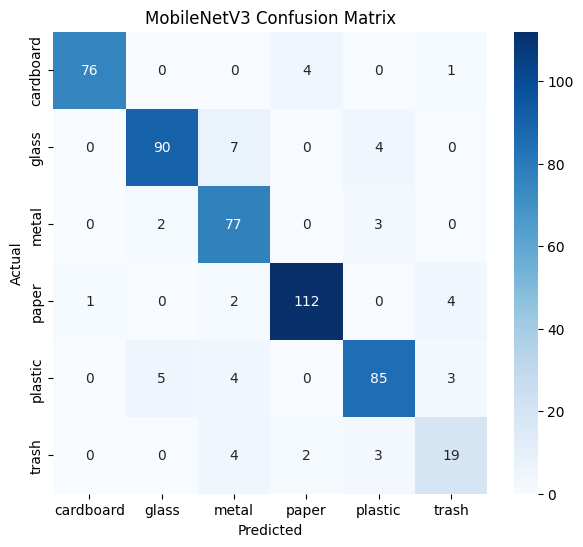

In [ ]:
val_gen_m.reset()
preds_m = mobilenet_model.predict(val_gen_m)
y_pred_m = np.argmax(preds_m, axis=1)
y_true_m = val_gen_m.classes

print(classification_report(y_true_m, y_pred_m, target_names=class_names_m))

cm_m = confusion_matrix(y_true_m, y_pred_m)
plt.figure(figsize=(7,6))
sns.heatmap(cm_m, annot=True, fmt="d", xticklabels=class_names_m, yticklabels=class_names_m, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("MobileNetV3 Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

accuracies = {
    "EfficientNet-B3": 89.37,
    "ResNet50": 80.00,
    "MobileNetV3": 90.35
}

comparison = pd.DataFrame(
    list(accuracies.items()),
    columns=["Model", "Validation Accuracy (%)"]
)

print(comparison)

best_model = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_model]

print("\nBest Model:", best_model)
print("Best Validation Accuracy:", best_accuracy, "%")

             Model  Validation Accuracy (%)
0  EfficientNet-B3                    89.37
1         ResNet50                    80.00
2      MobileNetV3                    90.35

Best Model: MobileNetV3
Best Validation Accuracy: 90.35 %


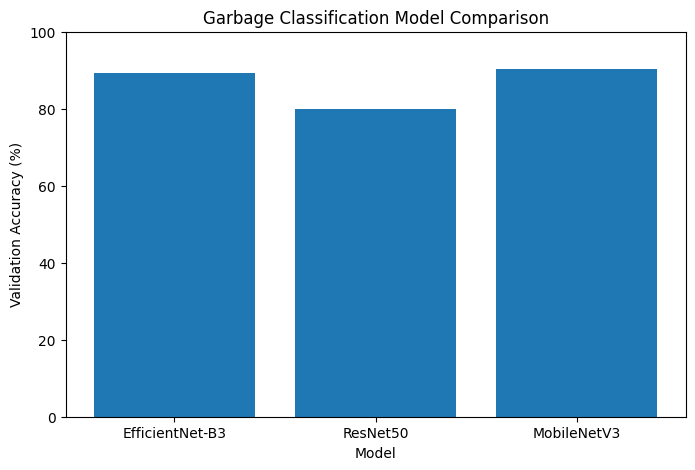

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Validation Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Validation Accuracy (%)")
plt.title("Garbage Classification Model Comparison")
plt.ylim(0, 100)

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, shutil, random

# Point back to your original extracted data (before train/val split)
DATA_DIR = None
expected_classes = {"cardboard", "glass", "metal", "paper", "plastic", "trash"}
search_root = "/content/drive/MyDrive/garbage_classification/data"

for root, dirs, files_ in os.walk(search_root):
    if expected_classes.issubset(set(d.lower() for d in dirs)):
        DATA_DIR = root
        break

print("Source data found at:", DATA_DIR)

TEST_BASE_DIR = "/content/drive/MyDrive/garbage_classification/garbage_split_with_test"
if os.path.exists(TEST_BASE_DIR):
    shutil.rmtree(TEST_BASE_DIR)

classes = [c for c in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, c))]
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15

for cls in classes:
    src = os.path.join(DATA_DIR, cls)
    imgs = [f for f in os.listdir(src) if not f.startswith(".")]
    random.seed(42)  # reproducible split
    random.shuffle(imgs)

    n = len(imgs)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)

    splits = {
        "train": imgs[:train_end],
        "val": imgs[train_end:val_end],
        "test": imgs[val_end:]
    }

    for phase, subset in splits.items():
        dst = os.path.join(TEST_BASE_DIR, phase, cls)
        os.makedirs(dst, exist_ok=True)
        for img in subset:
            shutil.copy(os.path.join(src, img), os.path.join(dst, img))

print("Split created.")
for phase in ["train", "val", "test"]:
    print(f"\n{phase.upper()} counts:")
    print({c: len(os.listdir(f"{TEST_BASE_DIR}/{phase}/{c}")) for c in classes})

Source data found at: /content/drive/MyDrive/garbage_classification/data/Garbage classification/Garbage classification
Split created.

TRAIN counts:
{'cardboard': 282, 'glass': 350, 'metal': 287, 'paper': 415, 'plastic': 337, 'trash': 95}

VAL counts:
{'cardboard': 60, 'glass': 75, 'metal': 61, 'paper': 89, 'plastic': 72, 'trash': 20}

TEST counts:
{'cardboard': 61, 'glass': 76, 'metal': 62, 'paper': 90, 'plastic': 73, 'trash': 22}


In [ ]:

import os

BASE_DIR = "/content/drive/MyDrive/garbage_classification/garbage_split"
print(os.listdir(f"{BASE_DIR}/train"))

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
print(os.listdir("/content/drive/MyDrive/garbage_classification"))

['data', 'garbage_split', 'models', 'test_results.csv', 'garbage_split_with_test']


In [ ]:
import os
from PIL import Image


valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
removed = []

for phase in ["train", "val"]:
    for cls in os.listdir(f"{BASE_DIR}/{phase}"):
        folder = f"{BASE_DIR}/{phase}/{cls}"
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            ext = os.path.splitext(fname)[1].lower()

            if ext not in valid_extensions:
                os.remove(fpath)
                removed.append(fpath)
                continue

            try:
                img = Image.open(fpath)
                img.verify()
            except Exception:
                os.remove(fpath)
                removed.append(fpath)

print(f"Removed {len(removed)} bad/non-image files.")
for f in removed:
    print(" -", f)

Removed 0 bad/non-image files.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def mobilenet_manual_preprocess(img):
    return (img / 127.5) - 1.0

BATCH_SIZE = 32

test_gen_e = ImageDataGenerator(preprocessing_function=efficientnet_preprocess).flow_from_directory(
    f"{TEST_BASE_DIR}/test", target_size=(300, 300), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
test_gen_r = ImageDataGenerator(preprocessing_function=resnet_preprocess).flow_from_directory(
    f"{TEST_BASE_DIR}/test", target_size=(224, 224), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
test_gen_m = ImageDataGenerator(preprocessing_function=mobilenet_manual_preprocess).flow_from_directory(
    f"{TEST_BASE_DIR}/test", target_size=(224, 224), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

class_names = list(test_gen_e.class_indices.keys())
print("Classes:", class_names)

Found 384 images belonging to 6 classes.
Found 384 images belonging to 6 classes.
Found 384 images belonging to 6 classes.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
from tensorflow.keras.models import load_model
import os

# Correct paths based on where your models were actually saved
efficientnet_path = "/content/drive/MyDrive/garbage_classifier_efficientnetb3.keras"
resnet_path = "/content/drive/MyDrive/garbage_classifier_resnet50.keras"
mobilenet_path = "/content/drive/MyDrive/garbage_classification/models/garbage_classifier_mobilenetv3.keras"

print("EfficientNet exists:", os.path.exists(efficientnet_path))
print("ResNet50 exists:", os.path.exists(resnet_path))
print("MobileNetV3 exists:", os.path.exists(mobilenet_path))

EfficientNet exists: False
ResNet50 exists: False
MobileNetV3 exists: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_dir = "/content/drive/MyDrive/garbage_classification/models"
print(os.listdir(save_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['garbage_classifier_efficientnetb3.keras', 'garbage_classifier_mobilenetv3.keras', 'class_indices_mobilenet.json', 'class_indices_resnet.json', 'garbage_classifier_resnet50.keras']


In [ ]:
from google.colab import files
uploaded = files.upload()

import shutil, os

save_dir = "/content/drive/MyDrive/garbage_classification/models"
os.makedirs(save_dir, exist_ok=True)

for fname in uploaded.keys():
    shutil.move(fname, f"{save_dir}/{fname}")
    print(f"Moved {fname} to Drive.")

Saving garbage_classifier_resnet50.keras to garbage_classifier_resnet50.keras
Moved garbage_classifier_resnet50.keras to Drive.


In [ ]:
import os

save_dir = "/content/drive/MyDrive/garbage_classification/models"
print(os.listdir(save_dir))

['garbage_classifier_mobilenetv3.keras', 'class_indices_mobilenet.json', 'class_indices_resnet.json', 'garbage_classifier_resnet50.keras']


In [ ]:
from tensorflow.keras.models import load_model

save_dir = "/content/drive/MyDrive/garbage_classification/models"

resnet_model = load_model(f"{save_dir}/garbage_classifier_resnet50.keras")
print("ResNet50 loaded successfully.")

ResNet50 loaded successfully.


In [ ]:
import json

with open(f"{save_dir}/class_indices_resnet.json") as f:
    class_indices_resnet = json.load(f)

print(class_indices_resnet)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
from tensorflow.keras.models import load_model
import os

efficientnet_path = "/content/drive/MyDrive/garbage_classifier_efficientnetb3.keras"
resnet_path = "/content/drive/MyDrive/garbage_classification/models/garbage_classifier_resnet50.keras"
mobilenet_path = "/content/drive/MyDrive/garbage_classification/models/garbage_classifier_mobilenetv3.keras"

print("EfficientNet exists:", os.path.exists(efficientnet_path))
print("ResNet50 exists:", os.path.exists(resnet_path))
print("MobileNetV3 exists:", os.path.exists(mobilenet_path))

EfficientNet exists: False
ResNet50 exists: True
MobileNetV3 exists: True


In [ ]:
from tensorflow.keras.models import load_model

MODEL_DIR = "/content/drive/MyDrive/garbage_classification/models"

efficientnet_model = load_model(f"{MODEL_DIR}/garbage_classifier_efficientnetb3.keras")
resnet_model = load_model(f"{MODEL_DIR}/garbage_classifier_resnet50.keras")
mobilenet_model = load_model(f"{MODEL_DIR}/garbage_classifier_mobilenetv3.keras")

print("All three models loaded successfully.")

All three models loaded successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from sklearn.metrics import classification_report, confusion_matrix

def mobilenet_manual_preprocess(img):
    return (img / 127.5) - 1.0

MODEL_DIR = "/content/drive/MyDrive/garbage_classification/models"
print("Models available:", os.listdir(MODEL_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Models available: ['garbage_classifier_efficientnetb3.keras', 'garbage_classifier_mobilenetv3.keras', 'class_indices_mobilenet.json', 'class_indices_resnet.json', 'garbage_classifier_resnet50.keras']


In [ ]:
efficientnet_model = load_model(f"{MODEL_DIR}/garbage_classifier_efficientnetb3.keras")
resnet_model = load_model(f"{MODEL_DIR}/garbage_classifier_resnet50.keras")
mobilenet_model = load_model(f"{MODEL_DIR}/garbage_classifier_mobilenetv3.keras")

print("All three models loaded successfully.")

All three models loaded successfully.


In [ ]:
import shutil, random

TEST_BASE_DIR = "/content/drive/MyDrive/garbage_classification/garbage_split_with_test"

if os.path.exists(f"{TEST_BASE_DIR}/test"):
    print("Test split already exists. Using it directly.")
else:
    print("Creating test split...")
    DATA_DIR = None
    expected_classes = {"cardboard", "glass", "metal", "paper", "plastic", "trash"}
    search_root = "/content/drive/MyDrive/garbage_classification/data"

    for root, dirs, files_ in os.walk(search_root):
        if expected_classes.issubset(set(d.lower() for d in dirs)):
            DATA_DIR = root
            break

    classes = [c for c in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, c))]
    train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15

    for cls in classes:
        src = os.path.join(DATA_DIR, cls)
        imgs = [f for f in os.listdir(src) if not f.startswith(".")]
        random.seed(42)
        random.shuffle(imgs)

        n = len(imgs)
        train_end = int(n * train_ratio)
        val_end = train_end + int(n * val_ratio)

        splits = {"train": imgs[:train_end], "val": imgs[train_end:val_end], "test": imgs[val_end:]}

        for phase, subset in splits.items():
            dst = os.path.join(TEST_BASE_DIR, phase, cls)
            os.makedirs(dst, exist_ok=True)
            for img in subset:
                shutil.copy(os.path.join(src, img), os.path.join(dst, img))

    print("Test split created.")

classes = sorted(os.listdir(f"{TEST_BASE_DIR}/test"))
print("Classes:", classes)
print("Test counts:", {c: len(os.listdir(f"{TEST_BASE_DIR}/test/{c}")) for c in classes})

Test split already exists. Using it directly.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test counts: {'cardboard': 61, 'glass': 76, 'metal': 62, 'paper': 90, 'plastic': 73, 'trash': 22}


In [ ]:
BATCH_SIZE = 64

test_gen_e = ImageDataGenerator(preprocessing_function=efficientnet_preprocess).flow_from_directory(
    f"{TEST_BASE_DIR}/test", target_size=(300, 300), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
test_gen_r = ImageDataGenerator(preprocessing_function=resnet_preprocess).flow_from_directory(
    f"{TEST_BASE_DIR}/test", target_size=(224, 224), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
test_gen_m = ImageDataGenerator(preprocessing_function=mobilenet_manual_preprocess).flow_from_directory(
    f"{TEST_BASE_DIR}/test", target_size=(224, 224), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

class_names = list(test_gen_e.class_indices.keys())
print("Class indices:", test_gen_e.class_indices)

Found 384 images belonging to 6 classes.
Found 384 images belonging to 6 classes.
Found 384 images belonging to 6 classes.
Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
print("Testing EfficientNetB3...")
test_loss_e, test_acc_e = efficientnet_model.evaluate(test_gen_e, verbose=0)

print("Testing ResNet50...")
test_loss_r, test_acc_r = resnet_model.evaluate(test_gen_r, verbose=0)

print("Testing MobileNetV3...")
test_loss_m, test_acc_m = mobilenet_model.evaluate(test_gen_m, verbose=0)

print(f"\nEfficientNetB3 TEST accuracy: {test_acc_e*100:.2f}%")
print(f"ResNet50 TEST accuracy:       {test_acc_r*100:.2f}%")
print(f"MobileNetV3 TEST accuracy:    {test_acc_m*100:.2f}%")

Testing EfficientNetB3...
Testing ResNet50...
Testing MobileNetV3...

EfficientNetB3 TEST accuracy: 96.61%
ResNet50 TEST accuracy:       93.49%
MobileNetV3 TEST accuracy:    96.35%



==================== EfficientNetB3 TEST REPORT ====================
              precision    recall  f1-score   support

   cardboard       1.00      0.95      0.97        61
       glass       0.99      0.95      0.97        76
       metal       0.94      0.97      0.95        62
       paper       0.97      1.00      0.98        90
     plastic       0.97      0.97      0.97        73
       trash       0.87      0.91      0.89        22

    accuracy                           0.97       384
   macro avg       0.96      0.96      0.96       384
weighted avg       0.97      0.97      0.97       384



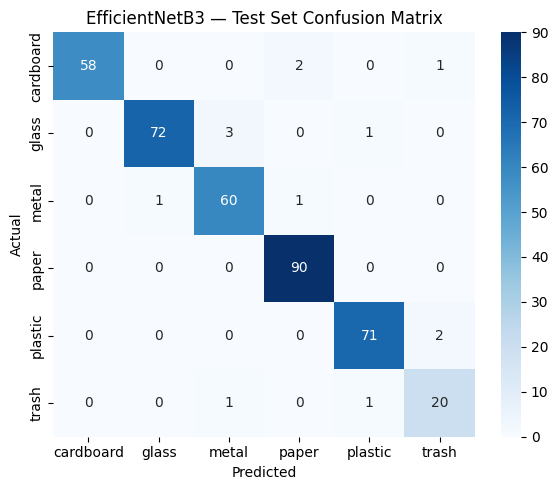


==================== ResNet50 TEST REPORT ====================
              precision    recall  f1-score   support

   cardboard       1.00      0.97      0.98        61
       glass       0.94      0.87      0.90        76
       metal       0.89      0.94      0.91        62
       paper       0.98      0.94      0.96        90
     plastic       0.91      0.95      0.93        73
       trash       0.81      1.00      0.90        22

    accuracy                           0.93       384
   macro avg       0.92      0.94      0.93       384
weighted avg       0.94      0.93      0.94       384



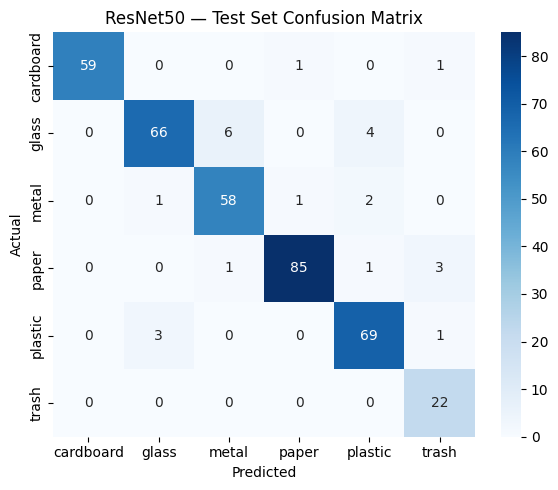


==================== MobileNetV3 TEST REPORT ====================
              precision    recall  f1-score   support

   cardboard       1.00      0.95      0.97        61
       glass       0.99      0.93      0.96        76
       metal       0.91      0.98      0.95        62
       paper       0.97      0.97      0.97        90
     plastic       0.96      0.97      0.97        73
       trash       0.96      1.00      0.98        22

    accuracy                           0.96       384
   macro avg       0.96      0.97      0.97       384
weighted avg       0.96      0.96      0.96       384



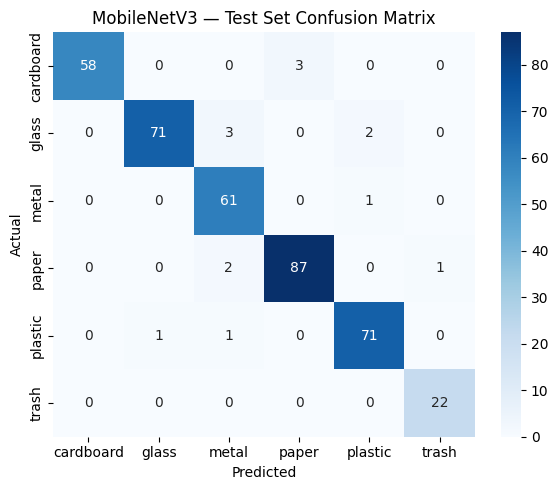

In [ ]:
def evaluate_and_plot(model, test_gen, model_name):
    test_gen.reset()
    preds = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    print(f"\n{'='*20} {model_name} TEST REPORT {'='*20}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title(f"{model_name} — Test Set Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

evaluate_and_plot(efficientnet_model, test_gen_e, "EfficientNetB3")
evaluate_and_plot(resnet_model, test_gen_r, "ResNet50")
evaluate_and_plot(mobilenet_model, test_gen_m, "MobileNetV3")

In [ ]:
test_results_df = pd.DataFrame({
    "Model": ["EfficientNetB3", "ResNet50", "MobileNetV3"],
    "Test Accuracy (%)": [test_acc_e*100, test_acc_r*100, test_acc_m*100],
    "Test Loss": [test_loss_e, test_loss_r, test_loss_m]
}).sort_values("Test Accuracy (%)", ascending=False).reset_index(drop=True)

print(test_results_df.to_string(index=False))

test_results_df.to_csv("/content/drive/MyDrive/garbage_classification/test_results.csv", index=False)
print("\nSaved test_results.csv to Drive.")

         Model  Test Accuracy (%)  Test Loss
EfficientNetB3          96.614581   0.148392
   MobileNetV3          96.354169   0.570820
      ResNet50          93.489581   0.178445

Saved test_results.csv to Drive.


In [ ]:
recycling_advice = {
    "cardboard": "Recyclable — flatten and place in paper/cardboard recycling.",
    "glass": "Recyclable — rinse and place in glass recycling bin.",
    "metal": "Recyclable — rinse cans, place in metal recycling.",
    "paper": "Recyclable — keep dry, place in paper recycling.",
    "plastic": "Check resin code; most PET/HDPE plastics are recyclable.",
    "trash": "Not recyclable — dispose in general waste.",
}

def classify_and_recommend(img_path, model, preprocess_fn, img_size, model_name="Model"):
    img = load_img(img_path, target_size=img_size)
    arr = img_to_array(img)
    arr = preprocess_fn(arr)
    arr = np.expand_dims(arr, axis=0)

    pred = model.predict(arr, verbose=0)[0]
    idx = np.argmax(pred)
    label = class_names[idx]
    confidence = pred[idx] * 100

    print(f"[{model_name}] Predicted: {label} ({confidence:.1f}% confidence)")
    print(f"Recommendation: {recycling_advice.get(label, 'No advice available.')}")
    return label, confidence

# Example — test on a sample from the test folder (EfficientNetB3)
sample_path = f"{TEST_BASE_DIR}/test/plastic/" + os.listdir(f"{TEST_BASE_DIR}/test/plastic")[0]
classify_and_recommend(sample_path, efficientnet_model, efficientnet_preprocess, (300,300), "EfficientNetB3")

[EfficientNetB3] Predicted: plastic (100.0% confidence)
Recommendation: Check resin code; most PET/HDPE plastics are recyclable.


('plastic', np.float32(99.996635))

In [ ]:
num_images = 6
results = []

for i in range(num_images):
    print(f"\n{'='*15} Upload photo {i+1} of {num_images} {'='*15}")
    uploaded = files.upload()
    img_path = list(uploaded.keys())[0]

    print(f"\nTesting: {img_path}")
    label, confidence = classify_and_recommend(img_path, efficientnet_model, efficientnet_preprocess, (300,300), "EfficientNetB3")
    results.append((img_path, label, confidence))

print(f"\n{'='*20} SUMMARY {'='*20}")
for fname, label, conf in results:
    print(f"{fname} → {label} ({conf:.1f}%)")


=============== Upload photo 1 of 6 ===============


Saving images.carboad.avif to images.carboad (2).avif

Testing: images.carboad (2).avif
[EfficientNetB3] Predicted: cardboard (48.7% confidence)
Recommendation: Recyclable — flatten and place in paper/cardboard recycling.

=============== Upload photo 2 of 6 ===============


Saving image.metal.jpeg to image.metal (3).jpeg

Testing: image.metal (3).jpeg
[EfficientNetB3] Predicted: metal (98.0% confidence)
Recommendation: Recyclable — rinse cans, place in metal recycling.

=============== Upload photo 3 of 6 ===============


Saving images.glass.jpg to images.glass (2).jpg

Testing: images.glass (2).jpg
[EfficientNetB3] Predicted: glass (99.6% confidence)
Recommendation: Recyclable — rinse and place in glass recycling bin.

=============== Upload photo 4 of 6 ===============


Saving paper.image.png to paper.image (1).png

Testing: paper.image (1).png
[EfficientNetB3] Predicted: trash (74.1% confidence)
Recommendation: Not recyclable — dispose in general waste.

=============== Upload photo 5 of 6 ===============


Saving image.plastic.webp to image.plastic.webp

Testing: image.plastic.webp
[EfficientNetB3] Predicted: plastic (55.4% confidence)
Recommendation: Check resin code; most PET/HDPE plastics are recyclable.

=============== Upload photo 6 of 6 ===============


Saving trash.image.jpg to trash.image.jpg

Testing: trash.image.jpg
[EfficientNetB3] Predicted: trash (80.1% confidence)
Recommendation: Not recyclable — dispose in general waste.

==================== SUMMARY ====================
images.carboad (2).avif → cardboard (48.7%)
image.metal (3).jpeg → metal (98.0%)
images.glass (2).jpg → glass (99.6%)
paper.image (1).png → trash (74.1%)
image.plastic.webp → plastic (55.4%)
trash.image.jpg → trash (80.1%)


In [ ]:
actual_labels = ["cardboard", "metal", "glass", "paper", "plastic", "trash"]
predicted_labels = [label for (fname, label, conf) in results]

correct = sum([1 for a, p in zip(actual_labels, predicted_labels) if a == p])
total = len(actual_labels)
real_world_accuracy = (correct / total) * 100

print(f"Real-world test: {correct}/{total} correct")
print(f"Real-world accuracy: {real_world_accuracy:.2f}%")

print("\nDetailed comparison:")
for a, p, (fname, label, conf) in zip(actual_labels, predicted_labels, results):
    status = "✅" if a == p else "❌"
    print(f"{status} Actual: {a:<12} Predicted: {p:<12} Confidence: {conf:.1f}%")

Real-world test: 5/6 correct
Real-world accuracy: 83.33%

Detailed comparison:
✅ Actual: cardboard    Predicted: cardboard    Confidence: 48.7%
✅ Actual: metal        Predicted: metal        Confidence: 98.0%
✅ Actual: glass        Predicted: glass        Confidence: 99.6%
❌ Actual: paper        Predicted: trash        Confidence: 74.1%
✅ Actual: plastic      Predicted: plastic      Confidence: 55.4%
✅ Actual: trash        Predicted: trash        Confidence: 80.1%


In [ ]:
print("="*55)
print("FINAL MODEL PERFORMANCE SUMMARY — EfficientNetB3")
print("="*55)
print(f"Test Set Accuracy (Kaggle held-out):  {test_acc_e*100:.2f}%")
print(f"Real-World Accuracy (6 new photos):   {real_world_accuracy:.2f}%")

FINAL MODEL PERFORMANCE SUMMARY — EfficientNetB3
Test Set Accuracy (Kaggle held-out):  96.61%
Real-World Accuracy (6 new photos):   83.33%


In [ ]:
final_summary = """FINAL MODEL PERFORMANCE SUMMARY — EfficientNetB3

Test Set Accuracy (Kaggle held-out): 96.61%
Real-World Accuracy (6 new photos): 83.33%

Final Model: EfficientNet-B3
"""

save_path = "/content/drive/MyDrive/garbage_classification/final_model_performance.txt"

with open(save_path, "w") as f:
    f.write(final_summary)

print("Saved successfully!")
print(save_path)

Saved successfully!
/content/drive/MyDrive/garbage_classification/final_model_performance.txt


In [ ]:
import pandas as pd

summary_df = pd.DataFrame({
    "Metric": [
        "Test Set Accuracy (Kaggle held-out)",
        "Real-World Accuracy (6 new photos)"
    ],
    "Accuracy (%)": [
        96.61,
        83.33
    ]
})

save_path = "/content/drive/MyDrive/garbage_classification/final_model_performance.csv"

summary_df.to_csv(save_path, index=False)

print("Saved successfully!")
print(save_path)

Saved successfully!
/content/drive/MyDrive/garbage_classification/final_model_performance.csv


In [ ]:
!pip install streamlit --quiet
!pip install pyngrok --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 110.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
app_code = '''
import streamlit as st
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.preprocessing.image import img_to_array
from PIL import Image

st.set_page_config(page_title="Smart Garbage Classifier", page_icon="♻️", layout="centered")

@st.cache_resource
def load_my_model():
    MODEL_DIR = "/content/drive/MyDrive/garbage_classification/models"
    return load_model(f"{MODEL_DIR}/garbage_classifier_efficientnetb3.keras")

model = load_my_model()

class_names = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

recycling_advice = {
    "cardboard": "Recyclable — flatten and place in paper/cardboard recycling.",
    "glass": "Recyclable — rinse and place in glass recycling bin.",
    "metal": "Recyclable — rinse cans, place in metal recycling.",
    "paper": "Recyclable — keep dry, place in paper recycling.",
    "plastic": "Check resin code; most PET/HDPE plastics are recyclable.",
    "trash": "Not recyclable — dispose in general waste.",
}

st.title("♻️ Smart Garbage Classification & Recycling Recommendation Agent")
st.write("Upload a photo of garbage/trash to get instant classification and recycling advice.")

uploaded_file = st.file_uploader("Upload an image", type=["jpg", "jpeg", "png", "webp"])

if uploaded_file is not None:
    img = Image.open(uploaded_file).convert("RGB")
    st.image(img, caption="Uploaded Image", use_container_width=True)

    img_resized = img.resize((300, 300))
    arr = img_to_array(img_resized)
    arr = efficientnet_preprocess(arr)
    arr = np.expand_dims(arr, axis=0)

    pred = model.predict(arr, verbose=0)[0]
    idx = np.argmax(pred)
    label = class_names[idx]
    confidence = pred[idx] * 100

    st.subheader(f"Prediction: {label.upper()}")
    st.write(f"Confidence: {confidence:.1f}%")
    st.success(recycling_advice.get(label, "No advice available."))

    st.subheader("Confidence per class")
    probs_dict = {class_names[i]: float(pred[i]) for i in range(len(class_names))}
    st.bar_chart(probs_dict)
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py file updated.")

app.py file updated.


In [ ]:
from pyngrok import ngrok
NGROK_AUTH_TOKEN = "3Ho9Ffb73YkJig1Xl3OHouxEP7C_4bLxkN2sLF58df4gkoJuW"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

from pyngrok import ngrok
NGROK_AUTH_TOKEN = "3Ho9Ffb73YkJig1Xl3OHouxEP7C_4bLxkN2sLF58df4gkoJuW"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
print("Token set successfully.")

Token set successfully.


In [ ]:
import subprocess, time
from pyngrok import ngrok
ngrok.kill()
process = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])
time.sleep(5)

public_url = ngrok.connect(8501)
print("Your Streamlit app is live at:", public_url)

Your Streamlit app is live at: NgrokTunnel: "https://morally-sharper-quarterly.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
import shutil

shutil.copy("app.py", "/content/drive/MyDrive/garbage_classification/app.py")
print("app.py saved to Drive.")

app.py saved to Drive.


In [ ]:
import shutil
shutil.copy("/content/drive/MyDrive/garbage_classification/app.py", "app.py")

'app.py'